In [ ]:
import pandas as pd

In [ ]:
dc=pd.read_csv('/content/sales.csv')

In [ ]:
dc.head()

,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2


In [ ]:
dc.describe()

,sale_id,unit_price,quantity,tax,total_price,reward_points
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,10.836110,10.337000,7.758010,118.583900,6.057000
std,288.819436,5.775924,6.029908,6.538066,99.936441,9.350464
min,1.000000,1.020000,1.000000,0.080000,1.210000,0.000000
25%,250.750000,5.867500,5.000000,2.510000,38.380000,0.000000
50%,500.500000,10.615000,10.000000,5.870000,89.705000,0.000000
75%,750.250000,15.882500,16.000000,11.522500,176.072500,10.000000
max,1000.000000,20.980000,20.000000,28.390000,433.990000,43.000000


In [ ]:
dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sale_id           1000 non-null   int64  
 1   branch            1000 non-null   object 
 2   city              1000 non-null   object 
 3   customer_type     1000 non-null   object 
 4   gender            1000 non-null   object 
 5   product_name      1000 non-null   object 
 6   product_category  1000 non-null   object 
 7   unit_price        1000 non-null   float64
 8   quantity          1000 non-null   int64  
 9   tax               1000 non-null   float64
 10  total_price       1000 non-null   float64
 11  reward_points     1000 non-null   int64  
dtypes: float64(3), int64(3), object(6)
memory usage: 93.9+ KB


In [ ]:
dc.isnull().sum()

,0
sale_id,0
branch,0
city,0
customer_type,0
gender,0
product_name,0
product_category,0
unit_price,0
quantity,0
tax,0


In [ ]:
dc.duplicated().sum()

np.int64(0)

In [ ]:
dc['customer_type'].value_counts()

,count
customer_type,
Member,516
Normal,484


In [ ]:
dc.groupby('city')['customer_type'].value_counts()

city         customer_type
Chicago      Member           178
             Normal           152
Los Angeles  Normal           165
             Member           161
New York     Member           177
             Normal           167
Name: count, dtype: int64

In [ ]:
dc.groupby('product_name')['quantity'].sum().sort_values(ascending=False)

,quantity
product_name,
Shampoo,2238
Orange Juice,2183
Notebook,2165
Detergent,2010
Apple,1741


In [ ]:
dc['revenue']=dc['quantity']*dc['unit_price']

In [ ]:
dc['revenue'].sum()

np.float64(110825.89000000001)

In [ ]:
dc.groupby('city')['revenue'].sum().sort_values(ascending=False)

,revenue
city,
Chicago,39798.69
New York,37595.18
Los Angeles,33432.02


In [ ]:
dc.groupby('product_name')['revenue'].sum().sort_values(ascending=False)

,revenue
product_name,
Shampoo,25272.25
Notebook,23171.00
Orange Juice,23071.42
Detergent,20980.35
Apple,18330.87


In [ ]:
dc['revenue'].mean()

np.float64(110.82589000000002)

In [ ]:
dc.groupby('customer_type')['revenue'].sum()

,revenue
customer_type,
Member,59078.04
Normal,51747.85


In [ ]:
dc.groupby('gender')['revenue'].sum()

,revenue
gender,
Female,50715.35
Male,60110.54


In [ ]:
dc.groupby('gender')['revenue'].mean()

,revenue
gender,
Female,107.447775
Male,113.845720


In [ ]:
dc.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

,revenue
product_category,
Personal Care,25280.52
Fruits,24483.59
Beverages,21479.67
Household,20201.71
Stationery,19380.40


In [ ]:
import matplotlib.pyplot as plt

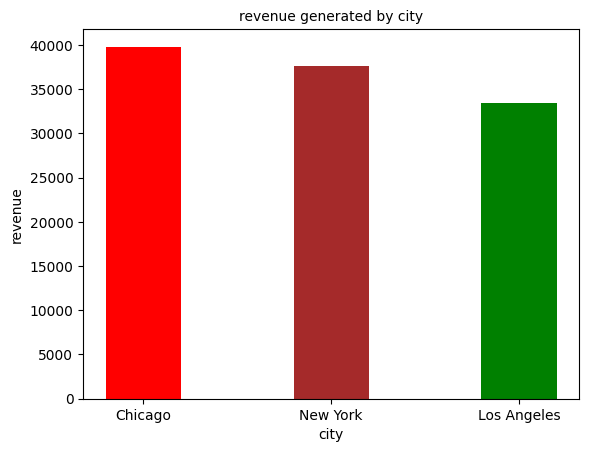

In [ ]:
s=dc.groupby('city')['revenue'].sum().sort_values(ascending=False)
c=('red','brown','green')
width=0.5
plt.bar(s.index,s.values,color=c,width=0.4)
plt.xlabel('city')
plt.ylabel('revenue')
plt.title('revenue generated by city')
plt.show()

Text(0, 0.5, 'revenue')

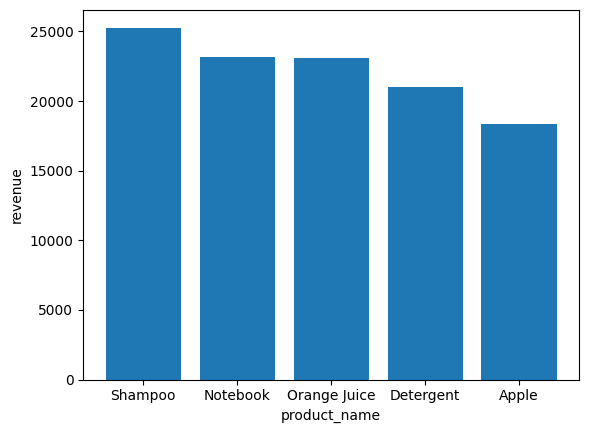

In [ ]:
f=dc.groupby('product_name')['revenue'].sum().sort_values(ascending=False)
c=('red','yellow','green')
plt.bar(f.index,f.values)
plt.grid(False)
plt.xlabel('product_name')
plt.ylabel('revenue')

In [ ]:
dc.groupby('city')[['quantity','revenue']].sum()

,quantity,revenue
city,,
Chicago,3638,39798.69
Los Angeles,3355,33432.02
New York,3344,37595.18


In [ ]:
dc.groupby(['gender','product_category'])['revenue'].sum()

gender  product_category
Female  Beverages           10322.92
        Fruits              11130.73
        Household            8420.24
        Personal Care       12347.93
        Stationery           8493.53
Male    Beverages           11156.75
        Fruits              13352.86
        Household           11781.47
        Personal Care       12932.59
        Stationery          10886.87
Name: revenue, dtype: float64

In [ ]:
dc.tail()

,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points,revenue
995,996,A,New York,Member,Female,Shampoo,Stationery,1.55,11,1.19,18.24,1,17.05
996,997,A,New York,Member,Male,Detergent,Personal Care,2.44,7,1.20,18.28,1,17.08
997,998,A,New York,Member,Female,Shampoo,Stationery,17.92,2,2.51,38.35,3,35.84
998,999,A,New York,Member,Female,Shampoo,Beverages,17.41,4,4.87,74.51,7,69.64
999,1000,A,New York,Normal,Male,Orange Juice,Stationery,4.11,4,1.15,17.59,0,16.44


In [ ]:
r=dc['revenue'].to_numpy()
p=dc['reward_points'].to_numpy()

In [ ]:
import numpy as np

In [ ]:
s=p[p>8]
print('reward points gift:',len(s))

reward points gift: 267


In [ ]:
print('max price:',np.max(r))
print('min price:',np.min(r))
print('avg price:',np.mean(r))

max price: 405.6
min price: 1.13
avg price: 110.82589000000002


In [ ]:
prod_rev = dc.groupby(['gender', 'product_name'])['revenue'].sum().reset_index()
top_revenue_by_gender = prod_rev.loc[prod_rev.groupby('gender')['revenue'].idxmax()]
print(top_revenue_by_gender)


   gender product_name   revenue
2  Female     Notebook  11611.80
9    Male      Shampoo  14402.44


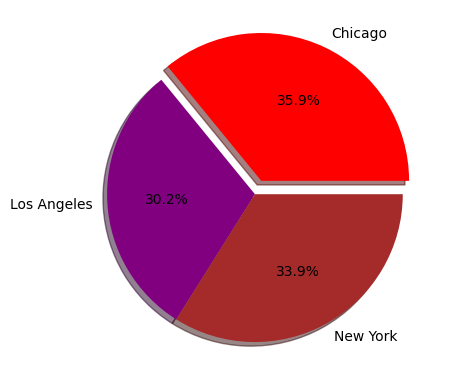

In [ ]:
import matplotlib.pyplot as plt
x=dc.groupby('city')['revenue'].sum()
explode=(0.1,0,0)
c=('red','purple','brown')
plt.pie(x.values,labels=x.index,autopct='%1.1f%%',explode=explode,shadow=True,colors=c)
plt.show()

In [ ]:
dc.groupby(['city','gender'])['revenue'].sum()


city         gender
Chicago      Female    17188.26
             Male      22610.43
Los Angeles  Female    14360.27
             Male      19071.75
New York     Female    19166.82
             Male      18428.36
Name: revenue, dtype: float64

<Figure size 800x800 with 0 Axes>

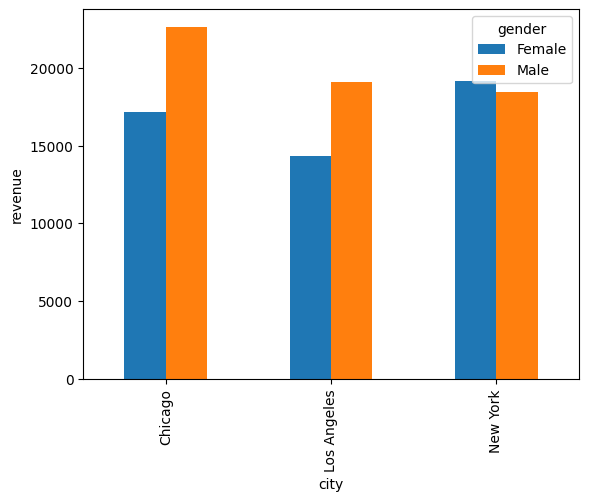

In [ ]:
g=dc.groupby(['city','gender'])['revenue'].sum().unstack()
plt.figure(figsize=(8,8))
g.plot(kind='bar')
plt.xlabel('city')
plt.ylabel('revenue')
plt.show()

In [ ]:
dc['city'].value_counts()

,count
city,
New York,344
Chicago,330
Los Angeles,326


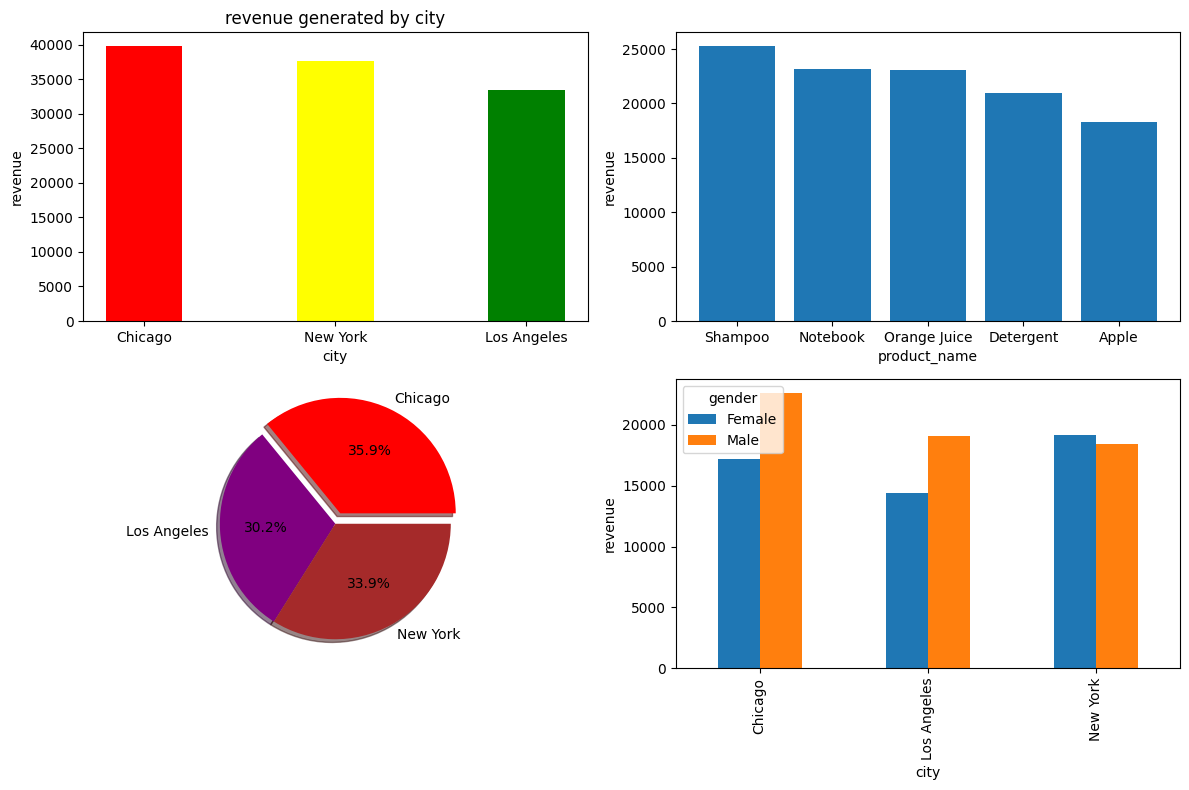

In [ ]:
plt.figure(figsize=(12, 8))


plt.subplot(2, 2, 1)
s = dc.groupby('city')['revenue'].sum().sort_values(ascending=False)
c = ('red', 'yellow', 'green')
plt.bar(s.index, s.values, color=c, width=0.4)
plt.xlabel('city')
plt.ylabel('revenue')
plt.title('revenue generated by city')


plt.subplot(2, 2, 2)
f = dc.groupby('product_name')['revenue'].sum().sort_values(ascending=False)
plt.bar(f.index, f.values)
plt.xlabel('product_name')
plt.ylabel('revenue')


plt.subplot(2, 2, 3)
x = dc.groupby('city')['revenue'].sum()
explode = (0.1, 0, 0)
c = ('red', 'purple', 'brown')
plt.pie(x.values, labels=x.index, autopct='%1.1f%%', explode=explode, shadow=True, colors=c)


plt.subplot(2, 2, 4)
g = dc.groupby(['city', 'gender'])['revenue'].sum().unstack()
g.plot(kind='bar', ax=plt.gca())  # <--- Assign to current axes
plt.xlabel('city')
plt.ylabel('revenue')

plt.tight_layout()
plt.show()